In [7]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
import pmdarima as pm


In [8]:
# metrics that will be used later

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred))) 


def ljung_box_test(residuals, is_seasonal, period):
    
    if is_seasonal:
        lb_df = acorr_ljungbox(residuals, period=period)
    else:
        max_lag = min([10, len(residuals)/5])
        
        lb_df = acorr_ljungbox(residuals, np.arange(1, max_lag+1, 1))

    fig, ax = plt.subplots()
    ax.plot(lb_df['lb_pvalue'], 'b-', label='p-values')
    ax.hlines(y=0.05, xmin=1, xmax=len(lb_df), color='black')
    plt.tight_layout()
    
    if all(pvalue > 0.05 for pvalue in lb_df['lb_pvalue']):
        print('All values are above 0.05. We fail to reject the null hypothesis. The residuals are uncorrelated')
    else:
        print('At least one p-value is smaller than 0.05')

In [9]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month.csv', parse_dates=['Date'])
df = df.set_index('Date')
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])

In [50]:
def normalize(df): 
    df['total_enc_norm'] = df.total_encounters / df.index.days_in_month  # normalize with days in month to acount for february for example
    df = df.drop('total_encounters', axis=1)
    return df
    
def revert(df):
    df['total_encounters'] = df.total_enc_norm * df.index.days_in_month
    df = df.drop('total_enc_norm', axis=1)
    return df

In [11]:
df = normalize(df)

In [12]:
df

,total_enc_norm
Date,
2018-01-01,440.548387
2018-02-01,436.857143
2018-03-01,422.612903
2018-04-01,428.066667
2018-05-01,445.064516
...,...
2025-04-01,484.966667
2025-05-01,485.387097
2025-06-01,495.466667


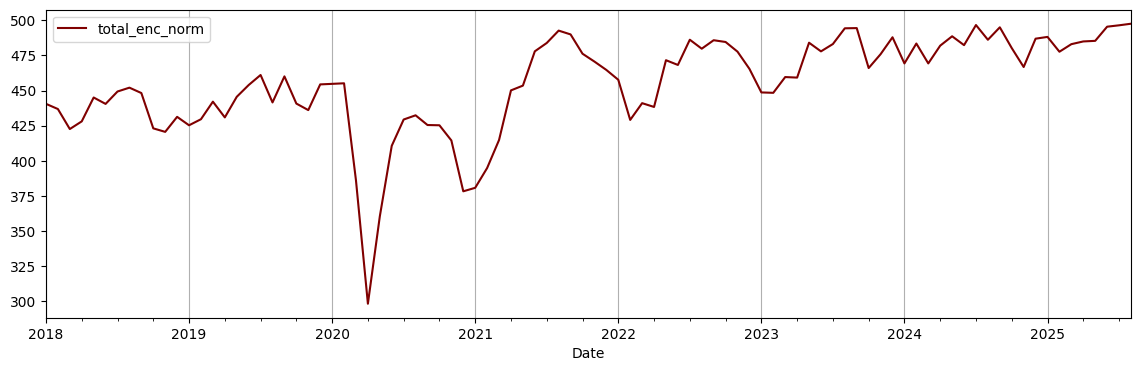

In [13]:
df.plot(
    kind='line',
    figsize=(14,4),
    color='maroon',
    label = 'total_enc / days_in_month'
)
plt.grid(axis='x')
plt.legend()
plt.show()

In [14]:
# Check stationarity
ad_index = adfuller(df['2021':])[0]
p_val = adfuller(df['2021':])[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')


Adfuller Index: -0.31365154249733285
p-val: 0.9235484881242906
Stationarity: False


In [15]:
# Make stationary
diff = np.diff(df.total_enc_norm, n=1)

ad_index = adfuller(diff[36:])[0]
p_val = adfuller(diff[36:])[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -6.747466429323355
p-val: 3.0095541151060984e-09
Stationarity: True


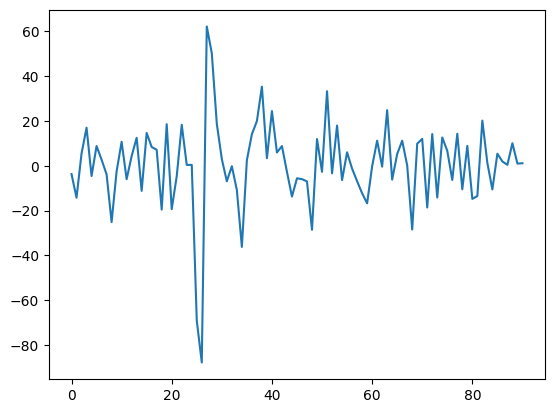

In [16]:
plt.plot(diff)

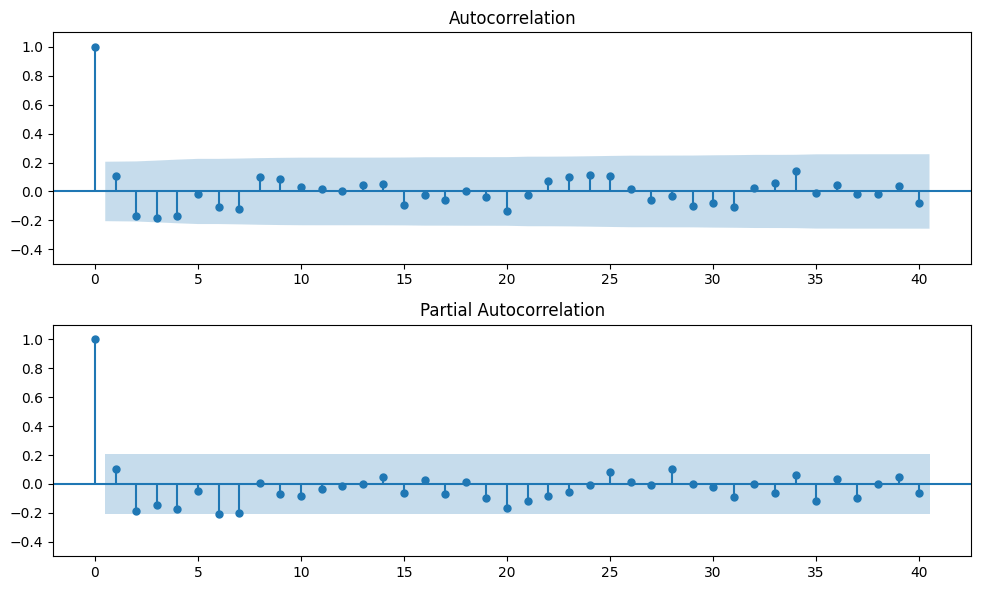

In [17]:
# Check ACF and PACF
LAGS = 40

fig, ax = plt.subplots(2,1, figsize=(10,6))

plot_acf(diff, lags=LAGS, ax=ax[0])
# ax[0].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[0].set_ylim(-.5,1.1)

plot_pacf(diff, lags=LAGS, ax=ax[1])
# ax[1].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[1].set_ylim(-.5,1.1)

plt.tight_layout()
plt.show()

We find possible seasonality pattern every 12 months. Let's try and verify it visually.

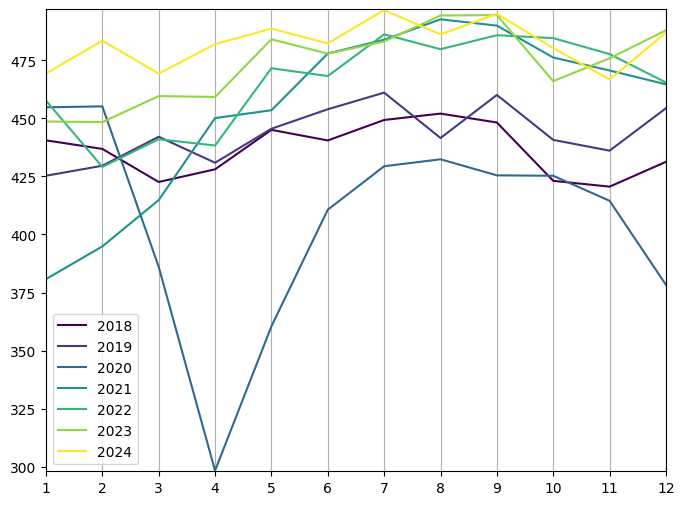

In [18]:
y_min_lim = np.int16(df.min()) 
y_max_lim = np.int16(df.max())

plt.figure(figsize=(8, 6))

cmap = plt.cm.viridis
years = range(2018, 2025)

for i, year in enumerate(years):
    plt.plot(
        df[df.index.year == year].to_numpy(),
        label=str(year),
        color=cmap(i / (len(years) - 1))
    )

plt.xlim(0,11)
plt.xticks(list(range(0,12,1)), labels=list(range(1,13,1)))
plt.ylim(y_min_lim, y_max_lim)
plt.legend()
plt.grid(axis='x')
plt.show()

Indeed, apart from 2020 there seems to be a pattern. We will see how we can handle the outlier year 2020.

So far we've taken care of a trend by taking the differences, and we have found a seasonality every 12 months, that's why we possibly need to take differences once more every 12 entries.



In [19]:
diff_12 = np.diff(diff, n=12)

# Check stationarity (redundant since we already have stationarity from diff = 1)

ad_index = adfuller(diff_12)[0]
p_val = adfuller(diff_12)[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -9.320007205372837
p-val: 9.951193421958718e-16
Stationarity: True


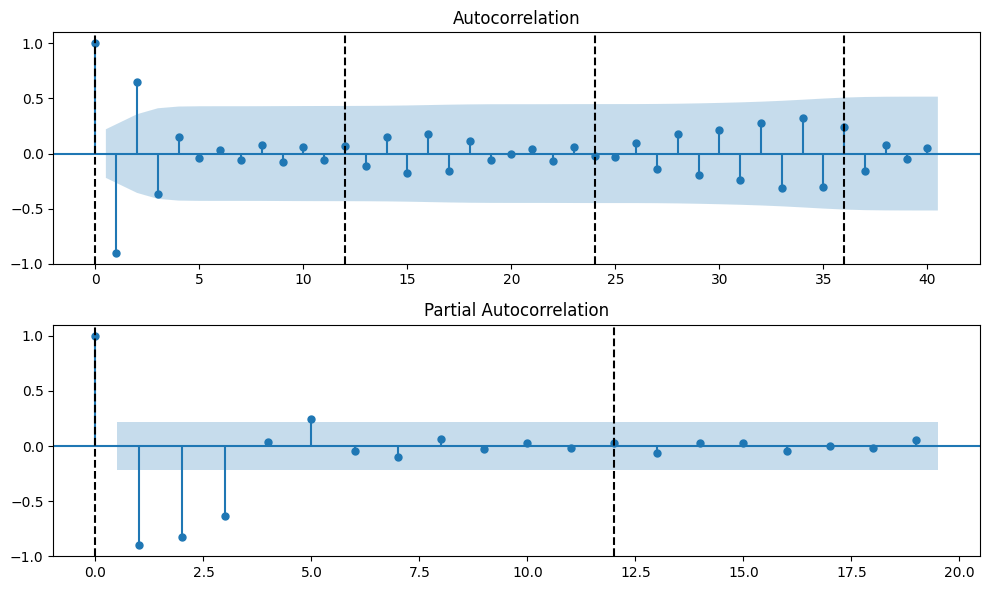

In [20]:
# Check ACF and PACF
LAGS = 40

fig, ax = plt.subplots(2,1, figsize=(10,6))

plot_acf(diff_12, lags=LAGS, ax=ax[0])
ax[0].vlines(list(range(0,LAGS,12)), ymin=-1, ymax=1.1, color='black', linestyle='--')
ax[0].set_ylim(-1,1.1)

plot_pacf(diff_12, lags=LAGS/2-1, ax=ax[1])
ax[1].vlines(list(range(0,int(LAGS/2-1),12)), ymin=-1, ymax=1.1, color='black', linestyle='--')
ax[1].set_ylim(-1,1.1)

plt.tight_layout()
plt.show()

In [21]:
# smoothen 2020 
mean_19_21 = (df.loc['2019-03':'2020-02', 'total_enc_norm'].to_numpy() + df.loc['2021-03':'2022-02', 'total_enc_norm'].to_numpy()) / 2
df['total_enc_norm_c'] = df['total_enc_norm'].astype(float)
df.loc['2020-03':'2021-02', 'total_enc_norm_c'] = mean_19_21

train = df[df.index.year < 2025]
test = df[df.index.year >= 2025]

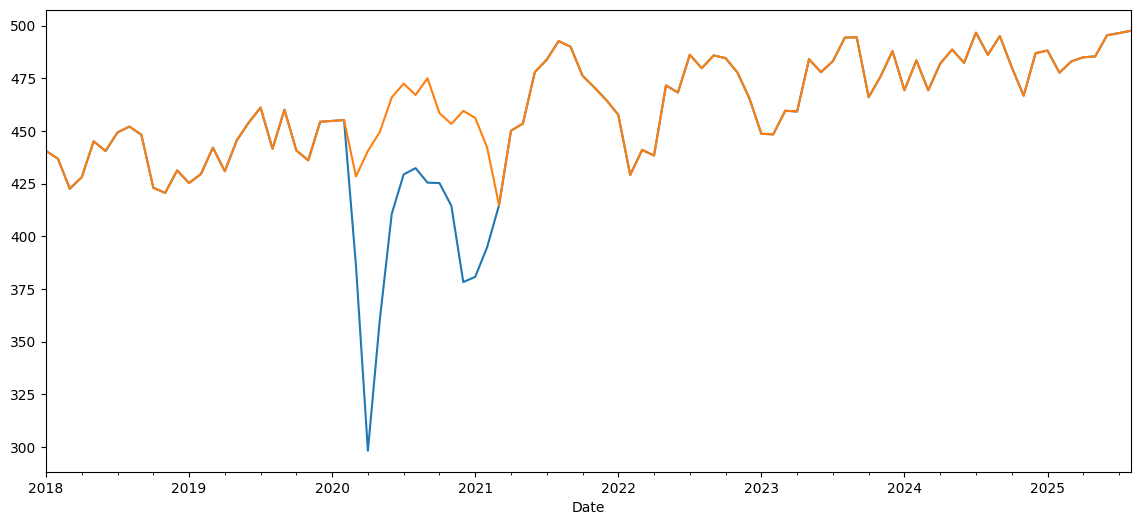

In [22]:
df.total_enc_norm.plot(figsize=(14,6))
df.total_enc_norm_c.plot(figsize=(14,6))
plt.show()

In [23]:
model = pm.auto_arima(
    y=train['total_enc_norm'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)

In [24]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   84
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -367.734
Date:                Sun, 25 Jan 2026   AIC                            737.467
Time:                        01:22:29   BIC                            739.886
Sample:                    01-01-2018   HQIC                           738.439
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       412.9045     34.387     12.007      0.000     345.506     480.303
===================================================================================
Ljung-Box (L1) (Q):                   0.99   Jarque-Bera (JB):               101.47
Prob(Q):                              0.32   Prob(JB):                         0.00
Heteroskedasticity (H):               0.24   Skew:                            -0.96
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

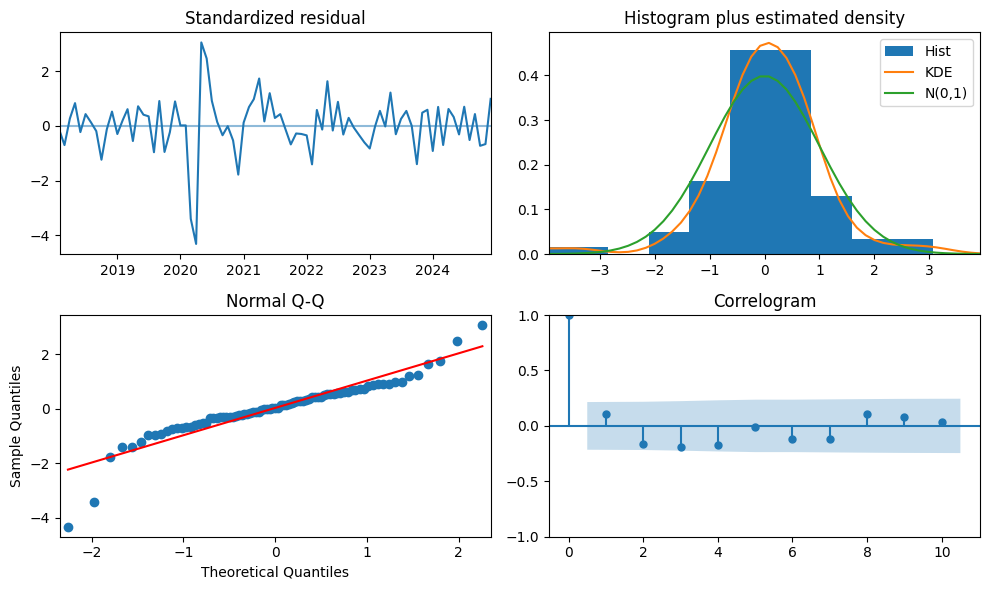

In [25]:
model.plot_diagnostics(figsize=(10,6))
plt.tight_layout()
plt.show()

In [26]:
preds = model.predict(n_periods=8)

All values are above 0.05. We fail to reject the null hypothesis. The residuals are uncorrelated


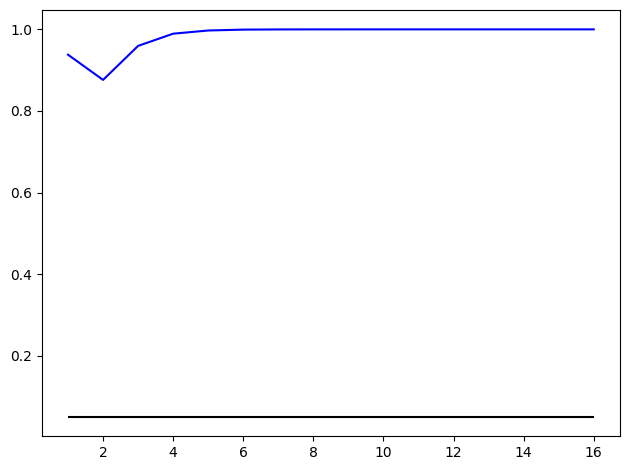

In [27]:
ljung_box_test(model.resid(), is_seasonal=True, period=12)

In [28]:
MAPE = mape(test['total_enc_norm'].to_numpy().flatten(), preds.to_numpy())
MAE = mae(test['total_enc_norm'].to_numpy().flatten(), preds.to_numpy())

In [29]:
df['is_2020_shock'] = 0
df.loc['2020-03-01':'2021-02-01', 'is_2020_shock'] = 1

train_exog = df.loc[train.index, 'is_2020_shock']
test_exog = df.loc[test.index, 'is_2020_shock']



model_with_exog = pm.auto_arima(
    y=train['total_enc_norm'],
    X=train_exog.to_numpy().reshape(-1,1),
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)


In [30]:
model_with_exog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   84
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -362.630
Date:                Sun, 25 Jan 2026   AIC                            729.260
Time:                        01:22:31   BIC                            734.098
Sample:                    01-01-2018   HQIC                           731.204
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1           -44.5286     10.503     -4.240      0.000     -65.113     -23.944
sigma2       365.0741     29.958     12.186      0.000     306.358     423.790
===================================================================================
Ljung-Box (L1) (Q):                   0.55   Jarque-Bera (JB):               100.63
Prob(Q):                              0.46   Prob(JB):                         0.00
Heteroskedasticity (H):               0.30   Skew:                            -0.64
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

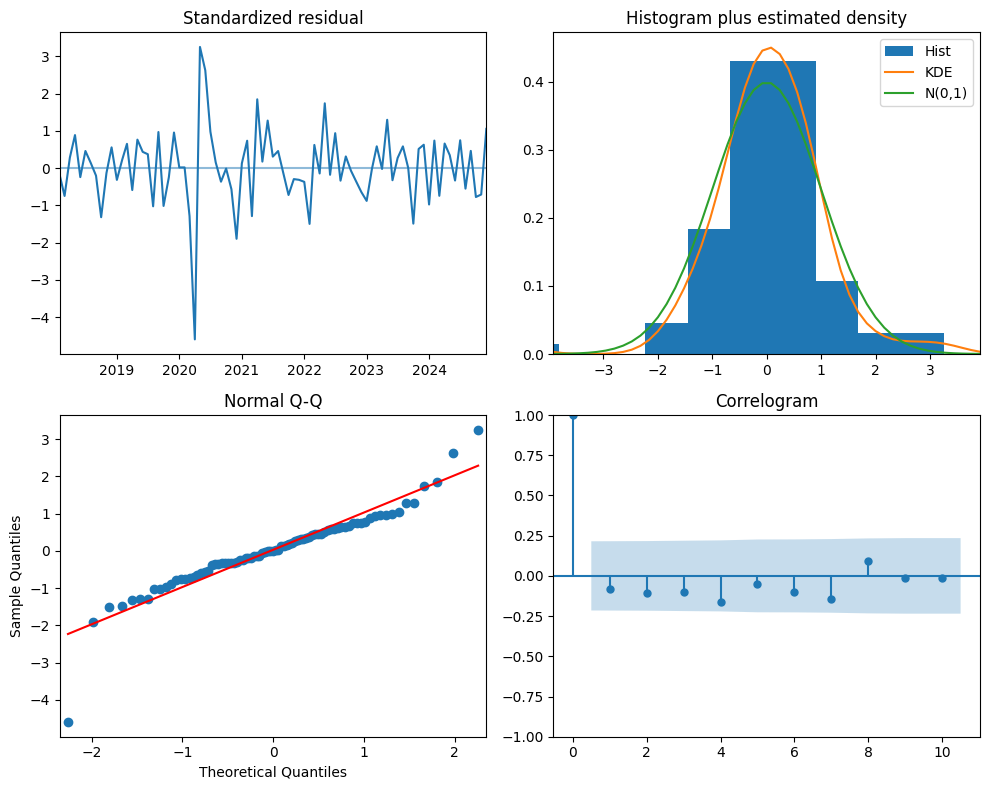

In [31]:
model_with_exog.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()


In [32]:
preds_x = model_with_exog.predict(n_periods=8, X=np.zeros((8,1)))
preds_x.to_numpy()
MAPE_x = mape(test['total_enc_norm'].to_numpy().flatten(), preds_x.to_numpy())
MAE_x = mae(test['total_enc_norm'].to_numpy().flatten(), preds_x.to_numpy())


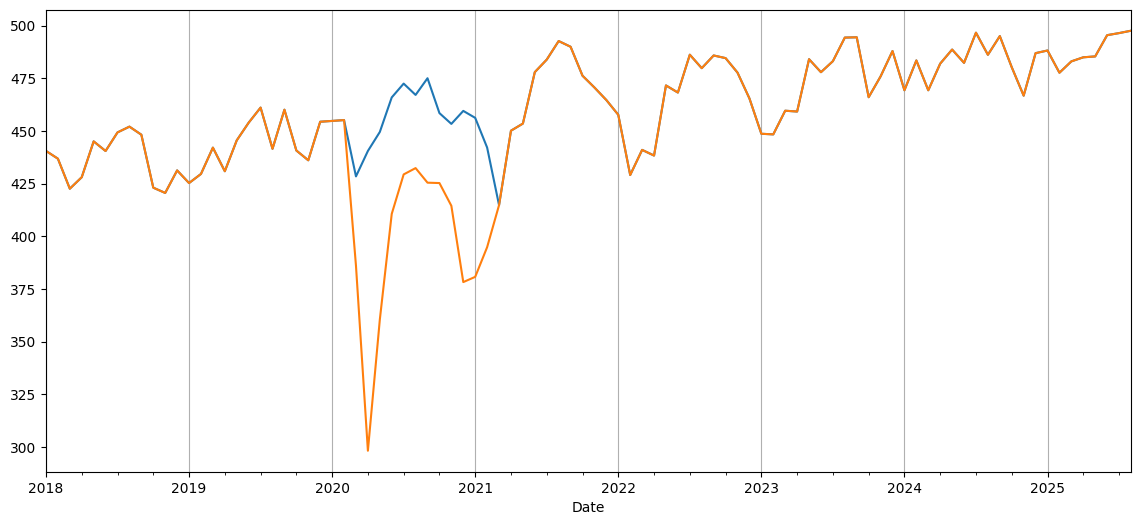

In [33]:
# smoothening the 2020 by interpolating the values from march 2020 to june 2020

df.total_enc_norm_c.plot(kind='line', figsize=(14,6))
df.total_enc_norm.plot(kind='line')
plt.grid(axis='x')
plt.show()

In [34]:
model_with_corrected = pm.auto_arima(
    y=train['total_enc_norm_c'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)
model_with_corrected.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                -320.160
Date:                             Sun, 25 Jan 2026   AIC                            648.320
Time:                                     01:22:40   BIC                            657.995
Sample:                                 01-01-2018   HQIC                           652.207
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3712      0.131      2.829      0.005       0.114       0.628
ma.L1         -0.9033      0.066    -13.609      0.000      -1.033      -0.773
ar.S.L12       0.5218      0.113      4.631      0.000       0.301       0.743
sigma2       124.2860     26.083      4.765      0.000      73.164     175.408
===================================================================================
Ljung-Box (L1) (Q):                   0.63   Jarque-Bera (JB):                 5.47
Prob(Q):                              0.43   Prob(JB):                         0.06
Heteroskedasticity (H):               0.86   Skew:                            -0.62
Prob(H) (two-sided):                  0.69   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

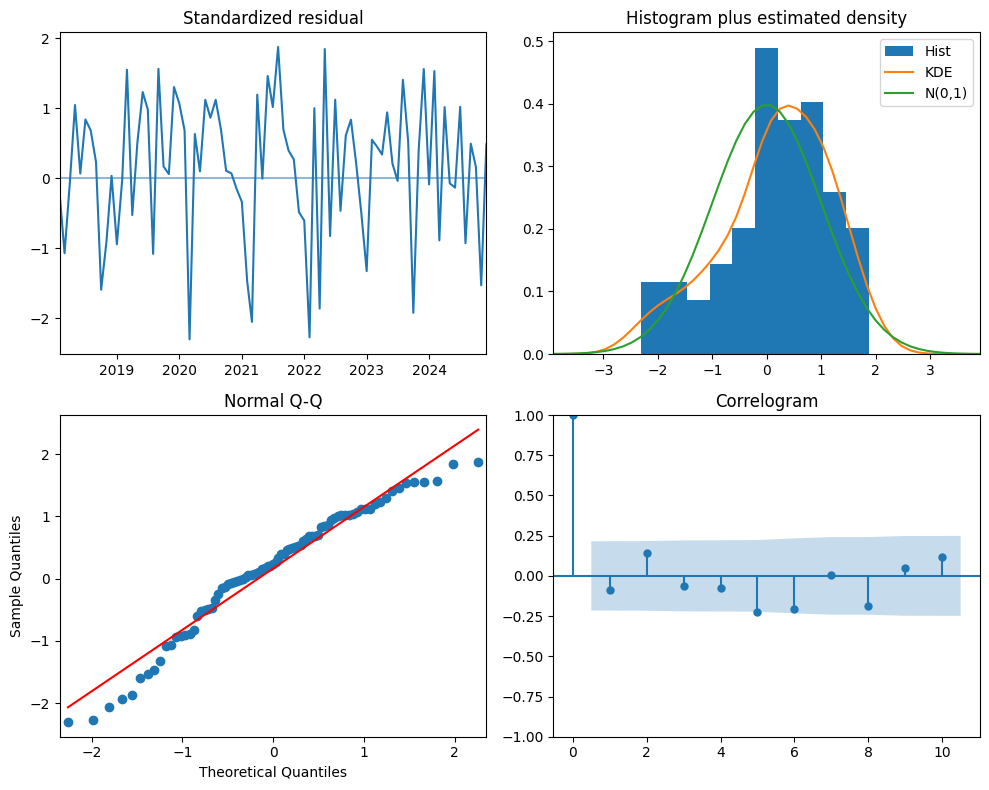

In [35]:
model_with_corrected.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()

In [36]:
preds_c = model_with_corrected.predict(n_periods=8)
MAPE_c = mape(test['total_enc_norm_c'].to_numpy().flatten(), preds_c.to_numpy())
MAE_c = mae(test['total_enc_norm_c'].to_numpy().flatten(), preds_c.to_numpy())

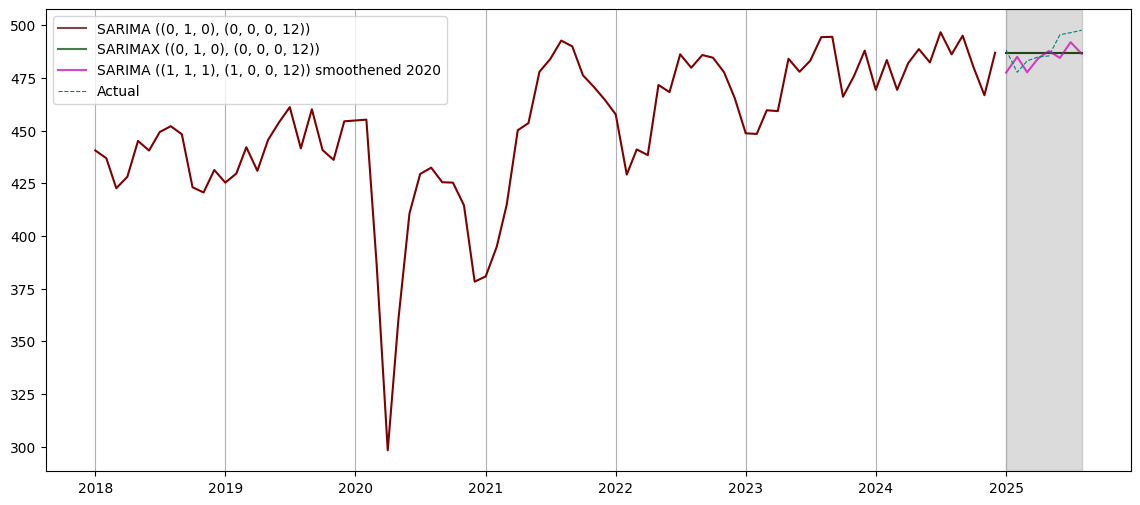

In [37]:
plt.figure(figsize=(14,6))
plt.plot(train['total_enc_norm'], color='maroon')
plt.plot(preds, color="#4D0000B8", label=f'SARIMA {model.get_params()['order'], model.get_params()['seasonal_order']}')
plt.plot(preds_x, color="#004D03B9",label=f'SARIMAX {model_with_exog.get_params()['order'], model_with_exog.get_params()['seasonal_order']}')
plt.plot(preds_c, color="#CB01B4B8", label=f'SARIMA {model_with_corrected.get_params()['order'], model_with_corrected.get_params()['seasonal_order']} smoothened 2020')

plt.plot(test['total_enc_norm'], linestyle='--', linewidth=0.8, color='teal', label='Actual')
plt.axvspan(test.index.min(), test.index.max(), color="#4D4D4D32", alpha=0.2)
plt.grid(axis='x')
# plt.xlim(19710)
# plt.ylim(11111)
plt.legend()
plt.show()

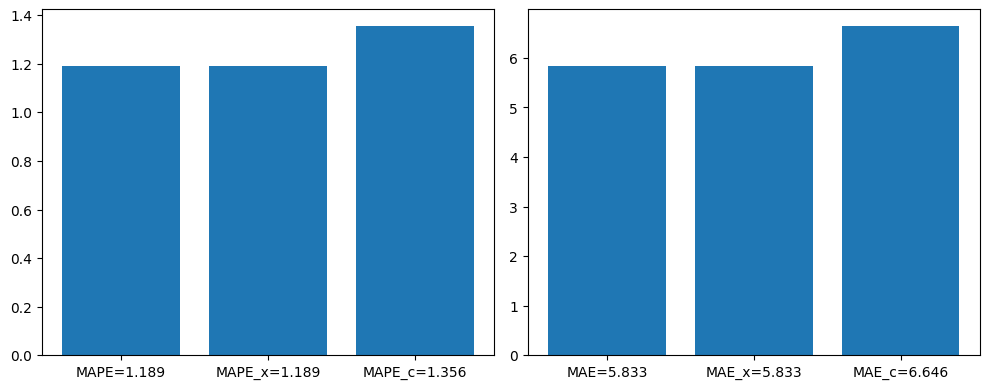

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].bar([f'MAPE={round(MAPE,3)}', f'MAPE_x={round(MAPE_x,3)}', f'MAPE_c={round(MAPE_c,3)}'], [MAPE, MAPE_x, MAPE_c])
ax[1].bar([f'MAE={round(MAE,3)}', f'MAE_x={round(MAE_x,3)}', f'MAE_c={round(MAE_c,3)}'], [MAE, MAE_x, MAE_c])
plt.tight_layout()
plt.show()

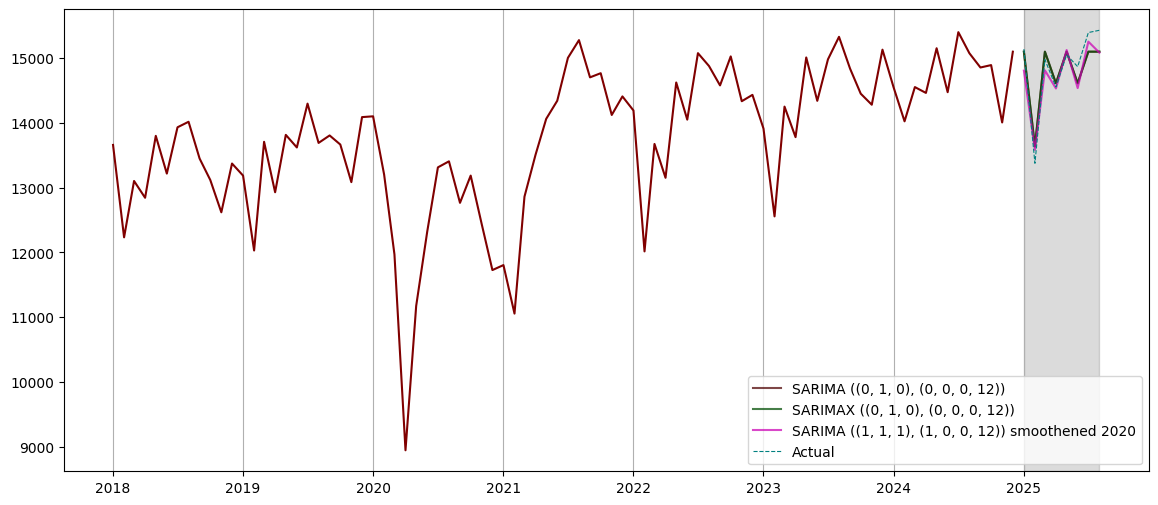

In [58]:
plt.figure(figsize=(14,6))
plt.plot(
    revert(train['total_enc_norm'].to_frame()),
    color='maroon'
)

plt.plot(
    revert(pd.DataFrame(preds, columns=['total_enc_norm'])),
    color="#4D0000B8",
    label=f'SARIMA {model.get_params()['order'],model.get_params()['seasonal_order']}'
)

plt.plot(
    revert(pd.DataFrame(preds_x, columns=['total_enc_norm'])),
    color="#004D03B9",
    label=f'SARIMAX {model_with_exog.get_params()['order'], model_with_exog.get_params()['seasonal_order']}'
)

plt.plot(revert(pd.DataFrame(preds_c, columns=['total_enc_norm'])), color="#CB01B4B8", label=f'SARIMA {model_with_corrected.get_params()['order'], model_with_corrected.get_params()['seasonal_order']} smoothened 2020')

plt.plot(revert(pd.DataFrame(test['total_enc_norm'])), linestyle='--', linewidth=0.8, color='teal', label='Actual')
plt.axvspan(test.index.min(), test.index.max(), color="#4D4D4D32", alpha=0.2)
plt.grid(axis='x')
# plt.xlim(19710)
# plt.ylim(11111)
plt.legend()
plt.show()